In [1]:
# create dataframe report id properly indexed to keep track of patients across different files
import pandas as pd
import gdown
import json

url = "https://drive.google.com/uc?id=15un_NsM_5vVV2hwegVtVu3V-j-SclXhP"
output = "data.json"

gdown.download(url, output, quiet=False)

with open(output, "r", encoding="utf-8") as f:
    data_index = json.load(f)

rows = []

for i, item in enumerate(data_index): # item is like {"0": {payload}} or {"1": {payload}}
    # item is like {"0": {payload}}
    payload = next(iter(item.values())) # get the payload dict from the item
    rows.append({ 
        "report_id": i,  # use the index as report_id to ensure uniqueness across files
        "text": payload.get("text"),
        "entities": payload.get("entities"),
        "data_split": payload.get("data_split"),
        "data_source": payload.get("data_source"),
        "num_entities": len(payload.get("entities", {})),
    })

df_index_complete = pd.DataFrame(rows)
df_index_complete["report_id"].nunique(), df_index_complete.head()
df_index_complete.shape 
df_index_complete.head()

Downloading...
From (original): https://drive.google.com/uc?id=15un_NsM_5vVV2hwegVtVu3V-j-SclXhP
From (redirected): https://drive.google.com/uc?id=15un_NsM_5vVV2hwegVtVu3V-j-SclXhP&confirm=t&uuid=8509a674-1464-40e3-b386-39ed1b208622
To: /Users/strangemax/syncthing/cirfolder/DATASCIENCE FOR HEALTH/Semester 2 /DASC512-202526/Assignment2/git12/512_2/data.json
100%|██████████| 237M/237M [00:18<00:00, 12.9MB/s] 


,report_id,text,entities,data_split,data_source,num_entities
0,0,Unchanged position of the left upper extremity...,"{'1': {'tokens': 'Unchanged', 'label': 'Observ...",inference,None,30
1,1,Unchanged position of the left upper extremity...,"{'1': {'tokens': 'Unchanged', 'label': 'Observ...",inference,None,30
2,2,There is redemonstration of right internal jug...,"{'1': {'tokens': 'central venous', 'label': 'A...",inference,None,26
3,3,Persistent small bilateral pleural effusions ....,"{'1': {'tokens': 'small', 'label': 'Observatio...",inference,None,28
4,4,Persistent small bilateral pleural effusions ....,"{'1': {'tokens': 'small', 'label': 'Observatio...",inference,None,28


In [2]:
# drop data data_split and data_source, num_entities columns since they are not needed for training
df_index_semi_data = df_index_complete.drop(columns=["data_split", "data_source", "num_entities"])
df_index_semi_data.head()

,report_id,text,entities
0,0,Unchanged position of the left upper extremity...,"{'1': {'tokens': 'Unchanged', 'label': 'Observ..."
1,1,Unchanged position of the left upper extremity...,"{'1': {'tokens': 'Unchanged', 'label': 'Observ..."
2,2,There is redemonstration of right internal jug...,"{'1': {'tokens': 'central venous', 'label': 'A..."
3,3,Persistent small bilateral pleural effusions ....,"{'1': {'tokens': 'small', 'label': 'Observatio..."
4,4,Persistent small bilateral pleural effusions ....,"{'1': {'tokens': 'small', 'label': 'Observatio..."


In [3]:
df_index_semi_data.shape

(57805, 3)

In [ ]:
# import main expanded dataset
import pandas as pd

# Google Sheets URL
url = "https://docs.google.com/spreadsheets/d/1kgc-vj6G1Ch2IPbJng5W54lpEq-SeXeh/export?format=csv"

# 2. Let pandas read the sheet URL directly from the cloud into memory
df_raw = pd.read_csv(url)

rows = []

# Iterate through the rows of the sheet and extract the features
for i, row in df_raw.iterrows():
    # .get() in case there are missing data cells
    rows.append({ 
        "report_id": row.get("report_id", i), # fallback to loop index if column missing
        "text": row.get("text"),
        "former": row.get("former")
    })

# Construct the final training DataFrame
df_labelled_data = pd.DataFrame(rows)

# Output validation metrics
print(f"Total Unique Reports: {df_labelled_data['report_id'].nunique()}")
print(f"Matrix Dimension Profile: {df_labelled_data.shape}")
print("\nFirst 5 Rows Preview:")
print(df_labelled_data.head())

In [ ]:
df_labelled_by_femi = df_labelled_data.copy()
df_labelled_by_femi.head()

,report_id,text,former
0,5333,PA and lateral view of the chest demonstrates ...,0
1,23171,Right arm PICC terminates in the right atrium ...,0
2,23172,Right arm PICC terminates in the right atrium ...,0
3,27573,Sequence of portable chest films dated 7 / 23 ...,0
4,27574,Sequence of portable chest films dated 4 - 22 ...,0


In [7]:
# print text on text column in report_id 52232 to manuially check if the text is the same in both datasets
report_id_to_check = 52232
labelled_text = df_labelled_data[df_labelled_data["report_id"] == report_id_to_check]["text"].values[0]
unlabelled_text = df_index_semi_data[df_index_semi_data["report_id"] == report_id_to_check]["text"].values[0]  
print(f"Labelled text for report_id {report_id_to_check}:\n{labelled_text}\n")
print(f"Unlabelled text for report_id {report_id_to_check}:\n{unlabelled_text}\n")


Labelled text for report_id 52232:
Mild elevation of left hemidiaphragm with linear opacities in keeping with atelectasis of the left lung base . No focal consolidation , pleural effusion , or pneumothorax . Multiple round pulmonary nodules throughout the right lung measuring up to 8 mm in size appear to have increased in size and number since 7 / 9 / 04 . Tortuous thoracic aorta . Normal cardiac size without pulmonary edema . No acute osseous abnormalities .

Unlabelled text for report_id 52232:
Mild elevation of left hemidiaphragm with linear opacities in keeping with atelectasis of the left lung base . No focal consolidation , pleural effusion , or pneumothorax . Multiple round pulmonary nodules throughout the right lung measuring up to 8 mm in size appear to have increased in size and number since 7 / 9 / 04 . Tortuous thoracic aorta . Normal cardiac size without pulmonary edema . No acute osseous abnormalities .



### vector extraction

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
import pandas as pd
import numpy as np
import os
from tqdm.auto import tqdm  # Clean, auto-selecting progress bar module

#CONFIGURE HARDWARE ACCELERATION
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using hardware device for extraction: {device}")

#LOAD PRE-TRAINED CLINICALBERT MODEL
print("Loading ClinicalBERT core transformer layers and tokenizer")
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bert_extractor = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT").to(device) # download and moves model to GPU
bert_extractor.eval()  # Set model to evaluation mode

#CUSTOM PYTORCH DATASET WRAPPER
class MasterEmbeddingDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        # Targets the text column and fills NaN values with empty strings and ensure all entries are strings for tokenization
        self.texts = df['text'].fillna('').astype(str).values
        self.tokenizer = tokenizer
        self.max_len = max_len
    # tell the DataLoader how many samples are in the dataset so it can manage batching and iteration
    def __len__(self):
        return len(self.texts)
    
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        # run text tokenization
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True, # adds [CLS] and [SEP] tokens for BERT
            max_length=self.max_len, # truncates long texts to fit the model's input size
            padding='max_length',
            truncation=True,
            return_attention_mask=True, # creates attention mask to differentiate real tokens from padding
            return_tensors='pt', # returns PyTorch tensors for model input
        )
        # Returns a structured Python dictionary containing the flattened 
        # token vectors and masks back to the calling function
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

# Instantiate dataset and batch loader (batch_size=64 optimizes Mac unified memory)
master_dataset = MasterEmbeddingDataset(df_index_semi_data, tokenizer)
master_loader = DataLoader(master_dataset, batch_size=64, shuffle=False)

#BATCH VECTOR EXTRACTION LOOP WITH PROGRESS BAR
all_embeddings = []

print(f"Extracting 768-dimensional features for {len(df_index_semi_data)} rows")

# Wrap the iterator in tqdm to render the real-time progress dashboard
with torch.no_grad(): # Disable gradient calculations for efficiency since we're only doing inference
    for batch in tqdm(master_loader, desc="Vectorizing Radiology Reports", unit="batch"):
        input_ids = batch['input_ids'].to(device) # Move token IDs to the GPU
        attention_mask = batch['attention_mask'].to(device) # Move attention masks to the GPU
        
        # Pushes batch strings into frozen BERT core layers
        outputs = bert_extractor(input_ids=input_ids, attention_mask=attention_mask)
        
        # Pull out the high-dimensional vector summary from the [CLS] token position (index 0)
        cls_vectors = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_vectors)

#SYNTHESIZE AND SERIALIZE MATRIX
master_embedding_matrix = np.vstack(all_embeddings)
print(f"\nfinished building master embedding matrix, the array shape is: {master_embedding_matrix.shape}")

# Save file directly to directory for reuse
os.makedirs('saved_models', exist_ok=True)
np.save('saved_models/master_clinical_embeddings.npy', master_embedding_matrix)
print("Saved master_clinical_embeddings.npy to disk.")

Using hardware device for extraction: mps
Loading ClinicalBERT core transformer layers and tokenizer
Extracting 768-dimensional features for 57805 rows


Vectorizing Radiology Reports:   0%|          | 0/904 [00:00<?, ?batch/s]


finished building master embedding matrix, the array shape is: (57805, 768)
Saved master_clinical_embeddings.npy to disk.


In [18]:
!pip install umap-learn hdbscan matplotlib seaborn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 12.7 MB/s eta 0:00:00a 0:00:01
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)


In [17]:
import numpy as np
import pandas as pd
import umap
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns
import os

# LOAD THE MATRIX AND MASTER DATA 
print("Loading high-dimensional embeddings")
# reads the raw 768-dimensional token summary embeddings
d768_embeddings = np.load('saved_models/master_clinical_embeddings.npy')

# Create a clean working copy of your 57,805 master dataframe
df_semi_supervised_analysis_data = df_index_semi_data.copy()

# DIMENSIONALITY REDUCTION WITH UMAP 
print("Compressing 768 dimensions down to 2D using UMAP")
# instantiate a UMAP compression blueprint
umap_compressed = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
# use umap to compress the high-dimensional embeddings into a 2D representation
embedding_2d = umap_compressed.fit_transform(d768_embeddings)

# Store coordinates in the analysis pool
# of the two dimensions UMAP creates assign them to new columns in the dataframe for easy access and visualization
df_semi_supervised_analysis_data['umap_x'] = embedding_2d[:, 0] # assign the first UMAP dimension to a new column 'umap_x' in the dataframe
df_semi_supervised_analysis_data['umap_y'] = embedding_2d[:, 1] # assign the second UMAP dimension to a new column 'umap_y' in the dataframe

# DENSITY CLUSTERING WITH HDBSCAN
print("Running HDBSCAN to isolate natural clinical clusters")
# instantiate the HDBSCAN clusterer with parameters that balance sensitivity to small clusters and noise
# min_cluster_size=100 means that Pockets with fewer than 100 reports are treated as unclassifiable anomalies rather than distinct clinical trends
clusterer = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=4, gen_min_span_tree=True, core_dist_n_jobs=1)
df_semi_supervised_analysis_data['cluster_label'] = clusterer.fit_predict(embedding_2d)

# Find the highest cluster label value
maximum_cluster_label = df_semi_supervised_analysis_data['cluster_label'].max()
#add 1 because cluster labels usually start from 0
number_of_clusters = maximum_cluster_label + 1
# Print the result
print(f"Discovered {number_of_clusters} clusters!")

# Count the number of occurrences of each cluster label
cluster_counts = df_semi_supervised_analysis_data['cluster_label'].value_counts()
# Print the cluster counts
print(cluster_counts)

Loading high-dimensional embeddings
Compressing 768 dimensions down to 2D using UMAP


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running HDBSCAN to isolate natural clinical clusters
Discovered 271 clusters!
cluster_label
-1      19249
 15     10051
 121      729
 163      670
 180      609
        ...  
 23        40
 139       40
 64        40
 0         40
 53        40
Name: count, Length: 272, dtype: int64


### CLUSTER MAP

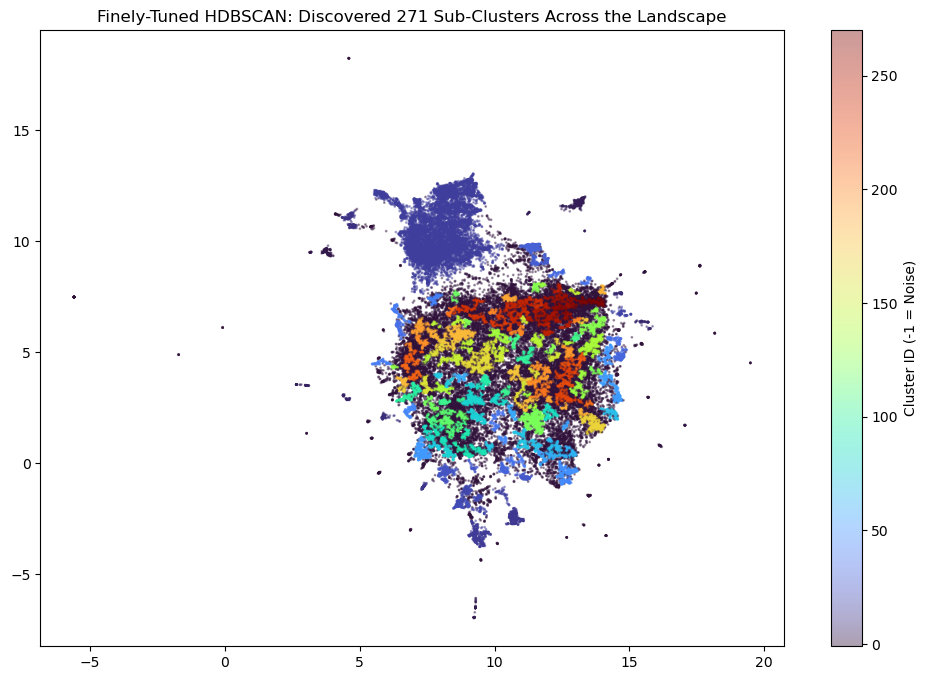

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_semi_supervised_analysis_data['umap_x'], 
    df_semi_supervised_analysis_data['umap_y'], 
    c=df_semi_supervised_analysis_data['cluster_label'], 
    cmap='turbo', # High contrast color map to easily see separate tiny clusters
    s=1, 
    alpha=0.4
)
plt.title(f"Finely-Tuned HDBSCAN: Discovered {number_of_clusters} Sub-Clusters Across the Landscape")
plt.colorbar(scatter, label='Cluster ID (-1 = Noise)')
plt.show()

### Save HDBSCAN Model & Data Mapping|

In [ ]:
import pickle
import os

# Create the directory if it doesn't exist
save_dir = 'saved_models'
os.makedirs(save_dir, exist_ok=True)

# SAVE THE HDBSCAN OBJECT
hdbscan_save_path = os.path.join(save_dir, 'hdbscan_205_clusters.pkl')
with open(hdbscan_save_path, 'wb') as f:
    pickle.dump(clusterer, f)
print(f"HDBSCAN clusterer object successfully frozen to: {hdbscan_save_path}")

# SAVE THE MATCHING UMAP COORDINATE DATA FRAME
# This locks the precise mapping of your 57,805 rows to these 205 clusters
csv_save_path = os.path.join(save_dir, 'final_205_cluster_results.csv')
df_semi_supervised_analysis_data.to_csv(csv_save_path, index=False)
print(f"Mapped spatial coordinates exported to: {csv_save_path}")

### Reload 205-Cluster Model Later

In [ ]:
# Whenever you want to return to this configuration in a brand new session, 
# you can bypass the entire clustering computation step and reload it instantly using this code:
import pickle
import pandas as pd

# Load the frozen spatial data
df_semi_supervised_analysis_data = pd.read_csv('saved_models/final_205_cluster_results.csv')

# Load the frozen clusterer model state
with open('saved_models/hdbscan_205_clusters.pkl', 'rb') as f:
    clusterer = pickle.load(f)

print("205-Cluster pipeline model successfully loaded from disk!")

### CROSS TAB

In [19]:
# isolate the columns we needed from your loaded Excel data frame
label_mapping = df_labelled_by_femi[['report_id', 'former']].rename(columns={'former': 'labelled_by_femi'})

# Merge labeled targets back into the 57k coordinate map using 'report_id'
df_semi_supervised_analysis_data = df_semi_supervised_analysis_data.merge(label_mapping, on='report_id', how='left')

# Select rows where the 'labelled_by_femi' column is not null
not_null_rows = df_semi_supervised_analysis_data['labelled_by_femi'].notnull()

# Use the boolean condition to filter the DataFrame
labelled_data_mask = df_semi_supervised_analysis_data[not_null_rows]

# STATISTICAL AUDIT CROSS-TABULATION 
print("\n Statistical Cross-Tabulation: Human Labels vs Unsupervised Clusters ")
# Safely handles either integer-encoded categories or continuous labels
cross_tab = pd.crosstab( # creates a contingency table that counts the frequency of each combination of cluster labels and human labels
    labelled_data_mask['cluster_label'], # the cluster labels assigned by HDBSCAN to the 57k reports
    labelled_data_mask['labelled_by_femi'], 
    margins=True # adds row and column totals to the cross-tabulation for easier interpretation of distributions
)
print(cross_tab)

print("\n--- Isolating High-Confidence Pseudo-Labels ---")

# Create a boolean mask to filter out the unconfident noise pool (-1)
high_confidence_mask = df_semi_supervised_analysis_data['cluster_label'] != -1

# Extract only the structurally sound, confident labeled rows
confident_pseudo_dataset = df_semi_supervised_analysis_data[high_confidence_mask]

# Print a status update of your expanded dataset size
print(f"Total reports in master pool: {len(df_semi_supervised_analysis_data)}")
print(f"Dropped as unconfident noise (-1): {len(df_semi_supervised_analysis_data) - len(confident_pseudo_dataset)}")
print(f"Successfully secured {len(confident_pseudo_dataset)} high-confidence labels")

# Save high-confidence dataset to a clean CSV file
os.makedirs('saved_models', exist_ok=True)
confident_pseudo_dataset.to_csv('saved_models/high_confidence_pseudo_labels_best_run.csv', index=False)
print("Saved high_confidence_pseudo_labels.csv to disk.")



 Statistical Cross-Tabulation: Human Labels vs Unsupervised Clusters 
labelled_by_femi  0.0  1.0  2.0  All
cluster_label                       
-1                 31   54   12   97
5                   0    1    0    1
6                   0    1    0    1
8                   0    0    1    1
15                  1   29    0   30
...               ...  ...  ...  ...
241                 0    1    0    1
243                 0    2    0    2
269                 1    0    0    1
270                 0    1    0    1
All                88  139   29  256

[72 rows x 4 columns]

--- Isolating High-Confidence Pseudo-Labels ---
Total reports in master pool: 57807
Dropped as unconfident noise (-1): 19249
Successfully secured 38558 high-confidence labels
Saved high_confidence_pseudo_labels.csv to disk.


### VISUALIZE LANDSCAPE WITH MASK OVERLAYS

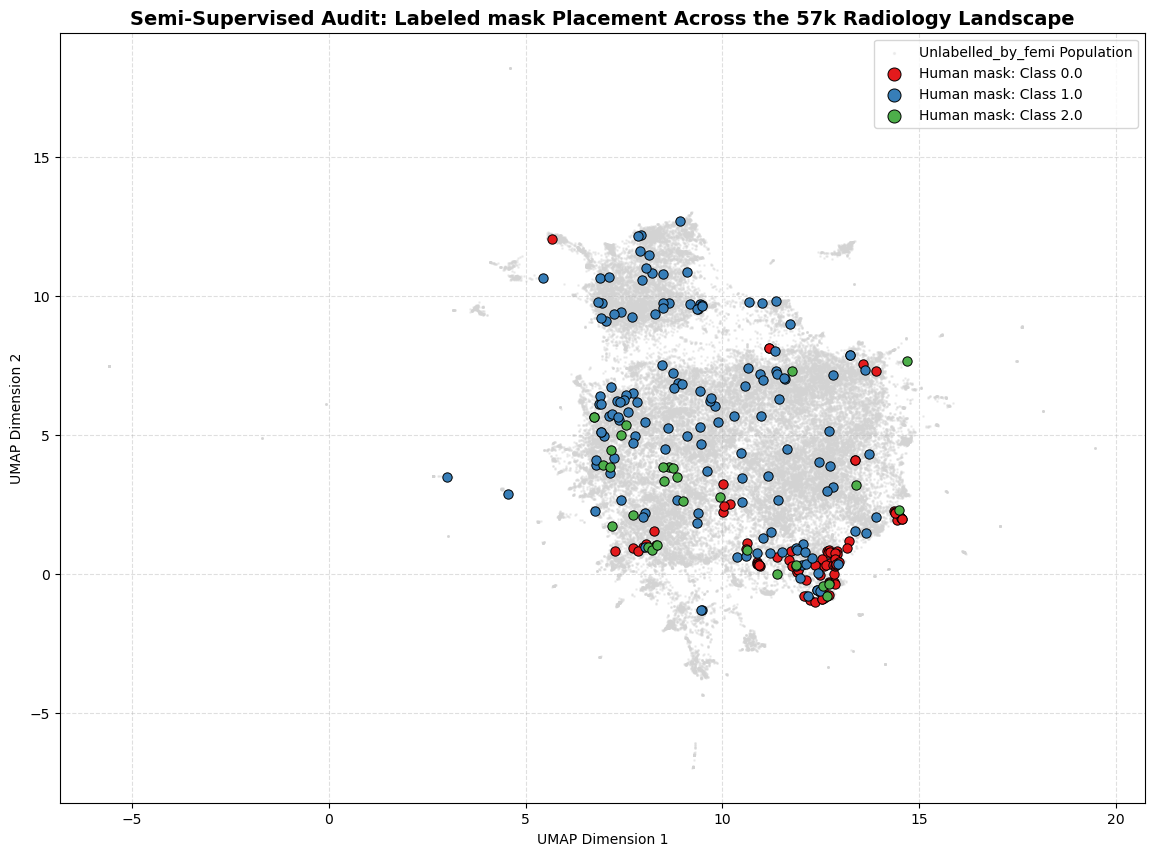

Full landscape spatial data exported to saved_models/unsupervised_clustering_results.csv


In [20]:
# VISUALIZE THE LANDSCAPE WITH MASK OVERLAYS 
plt.figure(figsize=(14, 10))

# Plot the background of 57,000+ unlabelled_by_femi cases in soft gray
plt.scatter(df_semi_supervised_analysis_data['umap_x'], df_semi_supervised_analysis_data['umap_y'], c='lightgray', s=1, alpha=0.3, label='Unlabelled_by_femi Population')

# Map and overlay unique labels present in your 'former' column
unique_labels = sorted(labelled_data_mask['labelled_by_femi'].unique())
# Dynamic color assignment to handle whatever numbering your 'former' column uses
color_palette = sns.color_palette("Set1", len(unique_labels))
color_map = dict(zip(unique_labels, color_palette))

for label_val in unique_labels:
    sub_set = labelled_data_mask[labelled_data_mask['labelled_by_femi'] == label_val]
    plt.scatter(
        sub_set['umap_x'], 
        sub_set['umap_y'], 
        c=[color_map[label_val]], 
        s=45, 
        edgecolors='black', 
        linewidths=0.7,
        label=f'Human mask: Class {label_val}', 
        zorder=5
    )

plt.title("Semi-Supervised Audit: Labeled mask Placement Across the 57k Radiology Landscape", fontsize=14, fontweight='bold')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(loc='best', markerscale=1.4, frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# SAVE CLUSTERING METADATA 
output_dir = 'saved_models'
df_semi_supervised_analysis_data.to_csv(os.path.join(output_dir, 'unsupervised_clustering_results.csv'), index=False)
print(f"Full landscape spatial data exported to {output_dir}/unsupervised_clustering_results.csv")

### OUTPUT SELECTED CLUSTER AS FILE

In [91]:
import pandas as pd
import os

# Load the landscape dataframe generated by HDBSCAN run
cluster_data_path = 'saved_models/unsupervised_clustering_results.csv'
df_landscape = pd.read_csv(cluster_data_path)

# Identify the target clusters where human 'Normal' anchors exclusively landed
normal_cluster_ids = [230, 265]

# Filter for unlabelled reports that live inside these exact dense coordinates
df_predicted_normal = df_landscape[
    (df_landscape['cluster_label'].isin(normal_cluster_ids)) & 
    (df_landscape['labelled_by_femi'].isnull())
]

print(f"Semi-Supervised 'Normal' Prediction Complete")
print(f"Total unlabelled records sitting in Normal Density Zones: {len(df_predicted_normal)}")

# Preview the text of predicted normal reports
print("\nSample text from predicted normal reports:")
for i, text in enumerate(df_predicted_normal['text'].head(3).values):
    print(f"\nReport {i+1}: {text[:150]}...")

# Export dataset
output_path = '/Users/strangemax/syncthing/cirfolder/DATASCIENCE FOR HEALTH/Semester 2 /DASC512-202526/Assignment2/git12/512_2/582_5D_predicted_normal_pool.xlsx'
df_predicted_normal[['report_id', 'cluster_label', 'text']].to_excel(output_path, index=False)
print(f"\nSuccessfully exported {len(df_predicted_normal)} predicted normal reports to: {output_path}")

Semi-Supervised 'Normal' Prediction Complete
Total unlabelled records sitting in Normal Density Zones: 0

Sample text from predicted normal reports:

Successfully exported 0 predicted normal reports to: /Users/strangemax/syncthing/cirfolder/DATASCIENCE FOR HEALTH/Semester 2 /DASC512-202526/Assignment2/git12/512_2/582_5D_predicted_normal_pool.xlsx


In [94]:
import pandas as pd
import os

# Load the landscape dataframe generated by HDBSCAN run
cluster_data_path = 'saved_models/unsupervised_clustering_results.csv'
df_landscape = pd.read_csv(cluster_data_path)

# Define the clusters where "Unsure" anchors naturally grouped
unsure_cluster_ids = [160, 201, 211, 319, 380, 428, 485, 502, 528]

# Filter for unlabelled reports sitting in these dense coordinates
df_predicted_unsure = df_landscape[
    (df_landscape['cluster_label'].isin(unsure_cluster_ids)) & 
    (df_landscape['labelled_by_femi'].isnull())
]

print(f"Semi-Supervised 'Unsure' Prediction Complete")
print(f"Total unlabelled records sitting in Mixed/Unsure Density Zones: {len(df_predicted_unsure)}")

# Preview the text of predicted unsure reports
print("\nSample text from predicted unsure/complex reports:")
for i, text in enumerate(df_predicted_unsure['text'].head(3).values):
    print(f"\nReport {i+1}: {text[:150]}...")

# Export dataset
output_path = '/Users/strangemax/syncthing/cirfolder/DATASCIENCE FOR HEALTH/Semester 2 /DASC512-202526/Assignment2/git12/512_2/582_5D_predicted_unsure_pool.xlsx'
df_predicted_unsure[['report_id', 'cluster_label', 'text']].to_excel(output_path, index=False)
print(f"\nSuccessfully exported {len(df_predicted_unsure)} predicted unsure reports to: {output_path}")

Semi-Supervised 'Unsure' Prediction Complete
Total unlabelled records sitting in Mixed/Unsure Density Zones: 511

Sample text from predicted unsure/complex reports:

Report 1: AP and lateral views of the chest , demonstrating near complete opacification of the left hemithorax with small area of improved aeration in the left ...

Report 2: AP and lateral views of the chest , demonstrating near complete opacification of the left hemithorax with small area of improved aeration in the left ...

Report 3: Tip of the endotracheal tube is at the level of the clavicles . Cardiomegaly with pulmonary edema and bilateral pleural effusions . More focal opaciti...

Successfully exported 511 predicted unsure reports to: /Users/strangemax/syncthing/cirfolder/DATASCIENCE FOR HEALTH/Semester 2 /DASC512-202526/Assignment2/git12/512_2/582_5D_predicted_unsure_pool.xlsx


In [ ]:
print("\n--- Mapping Cluster Topologies to Clinical Targets ---")

# 1. Determine the majority clinical label for every single dense cluster
# This counts which human label showed up most often inside each cluster ID
cluster_to_clinical_map = (
    labelled_data_mask.groupby('cluster_label')['labelled_by_femi']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    .to_dict()
)

# Remove the noise label from our mapping dictionary to protect the bottleneck
if -1 in cluster_to_clinical_map:
    del cluster_to_clinical_map[-1]

# Map consensus definitions onto the confident records
confident_pseudo_dataset = confident_pseudo_dataset.copy()
confident_pseudo_dataset['pseudo_target'] = confident_pseudo_dataset['cluster_label'].map(cluster_to_clinical_map)

# Drop any micro-clusters that didn't happen to capture a human validation anchor
clean_augmented_training_set = confident_pseudo_dataset.dropna(subset=['pseudo_target'])

print(f"Successfully mapped cluster configurations to clinical targets!")
print(f"Final Augmented Set size available for training: {len(clean_augmented_training_set)} rows.")
print("\nGenerated Pseudo-Target Distribution:")
print(clean_augmented_training_set['pseudo_target'].value_counts())

# Overwrite your export with the fully mapped clinical targets
clean_augmented_training_set.to_csv('saved_models/high_confidence_pseudo_labels_best_run.csv', index=False)
print("Saved fully-mapped high_confidence_pseudo_labels_best_run.csv to disk.")


--- Mapping Cluster Topologies to Clinical Targets ---
Successfully mapped cluster configurations to clinical targets!
Final Augmented Set size available for training: 19280 rows.

Generated Pseudo-Target Distribution:
pseudo_target
1.0    16420
0.0     1740
2.0     1120
Name: count, dtype: int64
Saved fully-mapped high_confidence_pseudo_labels_best_run.csv to disk.
